# SECTION 1 : EXPLORATION DES DONNÉES (EDA)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage inline
%matplotlib inline

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [22]:
# Dataset - IBM Telco
telco = pd.read_csv('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/data/telco_ibm.csv')

print("IBM Telco shape:", telco.shape)
print("\n✅ Datasets loaded!")

IBM Telco shape: (7043, 21)

✅ Datasets loaded!


In [23]:
print("=== IBM TELCO DATASET ===")
print("\nFirst 5 rows:")
telco.head()

=== IBM TELCO DATASET ===

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
print("=== IBM TELCO INFO ===")
telco.info()

=== IBM TELCO INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

# SECTION 2 : PREPROCESSING & FEATURE ENGINEERING

In [25]:
# Recharger le dataset proprement depuis zéro
telco = pd.read_csv('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/data/telco_ibm.csv')

# Supprimer customerID
if 'customerID' in telco.columns:
    telco.drop('customerID', axis=1, inplace=True)

# Corriger TotalCharges
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco['TotalCharges'] = telco['TotalCharges'].fillna(telco['TotalCharges'].median())

# Convertir Churn en 0/1 seulement si c'est encore Yes/No
if telco['Churn'].dtype == object:
    telco['Churn'] = telco['Churn'].map({'Yes': 1, 'No': 0})

print("✅ IBM Telco cleaned!")
print("Churn values:", telco['Churn'].unique())
print("Missing values:", telco.isnull().sum().sum())
print("Shape:", telco.shape)

✅ IBM Telco cleaned!
Churn values: [0 1]
Missing values: 0
Shape: (7043, 20)


In [26]:
from sklearn.model_selection import train_test_split

# Séparer features et target
X = telco.drop('Churn', axis=1)
y = telco['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nChurn distribution:")
print(y.value_counts())
print("\nChurn rate:", round(y.mean() * 100, 2), "%")

Features shape: (7043, 19)
Target shape: (7043,)

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.54 %


In [27]:
# Encodage des colonnes catégorielles
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Colonnes catégorielles:", cat_cols)

for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("✅ Encodage terminé!")
X.head()

Colonnes catégorielles: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
✅ Encodage terminé!


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [28]:
# Train/Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Split terminé!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Churn rate train:", round(y_train.mean() * 100, 2), "%")
print("Churn rate test:", round(y_test.mean() * 100, 2), "%")

✅ Split terminé!
X_train: (5634, 19)
X_test: (1409, 19)
Churn rate train: 26.54 %
Churn rate test: 26.54 %


In [29]:
# Save
path = 'C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/data/'

X_train.to_csv(path + 'X_train.csv', index=False)
X_test.to_csv(path + 'X_test.csv', index=False)
y_train.to_csv(path + 'y_train.csv', index=False)
y_test.to_csv(path + 'y_test.csv', index=False)
telco.to_csv(path + 'churn_final.csv', index=False)

print("✅ Tous les fichiers sauvegardés!")

✅ Tous les fichiers sauvegardés!


# SECTION 3 : ENTRAINEMENT LIGHTGBM

In [30]:
import lightgbm as lgb
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             classification_report, confusion_matrix)
import mlflow
import mlflow.lightgbm

# Démarrer MLflow
mlflow.set_experiment("churn_prediction")

with mlflow.start_run(run_name="LightGBM_v1"):
    
    # Paramètres du modèle
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'scale_pos_weight': 2,  # gère le déséquilibre 74/26
        'random_state': 42,
        'n_estimators': 300
    }
    
    # Entraînement
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)])
    
    # Prédictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Métriques
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    
    # Log dans MLflow
    mlflow.log_params(params)
    mlflow.log_metric("AUC_ROC", auc)
    mlflow.log_metric("Accuracy", acc)
    mlflow.lightgbm.log_model(model, "lightgbm_model")
    
    print("✅ Modèle entraîné!")
    print(f"AUC-ROC : {auc:.4f}")
    print(f"Accuracy : {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=['No Churn', 'Churn']))

2026/05/15 09:19:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 09:19:57 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 09:19:59 INFO mlflow.tracking.fluent: Experiment with name 'churn_prediction' does not exist. Creating a new experiment.


[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.84364
Early stopping, best iteration is:
[47]	valid_0's auc: 0.843883


2026/05/15 09:20:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 09:20:04 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Modèle entraîné!
AUC-ROC : 0.8439
Accuracy : 0.7850

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.82      0.85      1035
       Churn       0.58      0.69      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [31]:
# ============================================
# AMELIORATION DU MODELE - TUNING
# ============================================

with mlflow.start_run(run_name="LightGBM_v2_tuned"):
    
    params_tuned = {
        'objective': 'binary',
        'metric': 'auc',
        'learning_rate': 0.03,
        'num_leaves': 50,
        'max_depth': 6,
        'min_child_samples': 20,
        'scale_pos_weight': 3,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'random_state': 42,
        'n_estimators': 500
    }
    
    model_tuned = lgb.LGBMClassifier(**params_tuned)
    model_tuned.fit(X_train, y_train,
                    eval_set=[(X_test, y_test)],
                    callbacks=[lgb.early_stopping(50), 
                               lgb.log_evaluation(50)])
    
    y_pred_tuned = model_tuned.predict(X_test)
    y_pred_proba_tuned = model_tuned.predict_proba(X_test)[:, 1]
    
    auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)
    acc_tuned = accuracy_score(y_test, y_pred_tuned)
    
    mlflow.log_params(params_tuned)
    mlflow.log_metric("AUC_ROC", auc_tuned)
    mlflow.log_metric("Accuracy", acc_tuned)
    mlflow.lightgbm.log_model(model_tuned, "lightgbm_model_tuned")
    
    print("✅ Modèle tuné!")
    print(f"AUC-ROC : {auc_tuned:.4f}")
    print(f"Accuracy : {acc_tuned:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_tuned,
                                target_names=['No Churn', 'Churn']))

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004096 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

2026/05/15 09:22:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 09:22:51 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[21]	valid_0's auc: 0.846799
✅ Modèle tuné!
AUC-ROC : 0.8468
Accuracy : 0.7963

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.92      0.87      1035
   

In [32]:
import pickle
import os

# Créer le dossier models
os.makedirs('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/src', exist_ok=True)

# Sauvegarder le modèle V1 (meilleur recall)
model_path = 'C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/src/model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print("✅ Modèle V1 sauvegardé!")
print(f"Path: {model_path}")
print(f"\nRésumé final:")
print(f"  AUC-ROC  : {auc:.4f}")
print(f"  Accuracy : {acc:.4f}")
print(f"  Recall Churn : 69%  ← important pour détecter les churners")

✅ Modèle V1 sauvegardé!
Path: C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/src/model.pkl

Résumé final:
  AUC-ROC  : 0.8439
  Accuracy : 0.7850
  Recall Churn : 69%  ← important pour détecter les churners


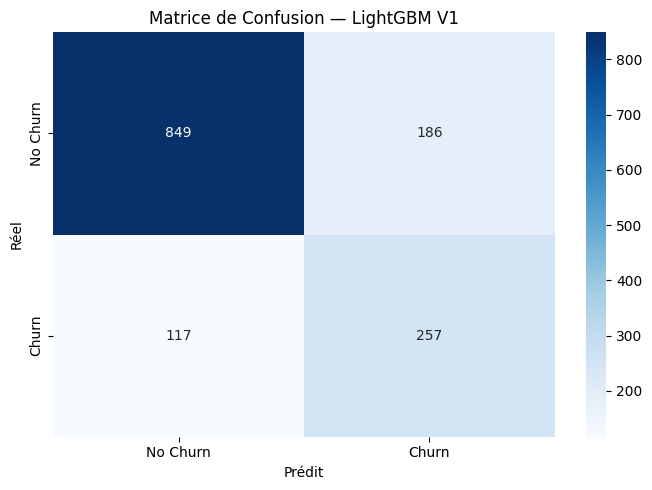

✅ Matrice sauvegardée!


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Matrice de Confusion — LightGBM V1')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/docs/confusion_matrix.png')
plt.show()
print("✅ Matrice sauvegardée!")

# SECTION 4 : EXPLICABILITÉ DU MODÈLE — SHAP & LIME (XAI)

In [34]:
import shap
import warnings
warnings.filterwarnings('ignore')

# Initialiser l'explainer SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values calculées!")
print("Shape SHAP values:", shap_values.shape)

✅ SHAP values calculées!
Shape SHAP values: (1409, 19)


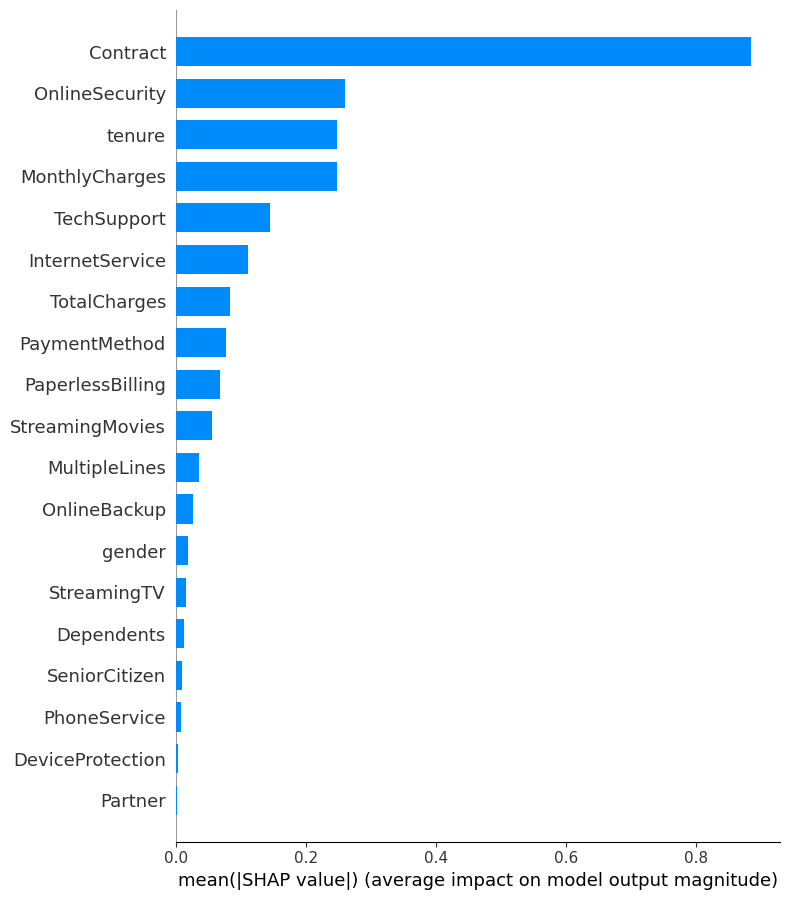

<Figure size 640x480 with 0 Axes>

In [35]:
# SHAP — Importance globale des features
shap.summary_plot(shap_values, X_test, 
                  plot_type="bar",
                  title="Importance Globale des Features")
plt.savefig('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/docs/shap_global_bar.png',
            bbox_inches='tight')
plt.show()

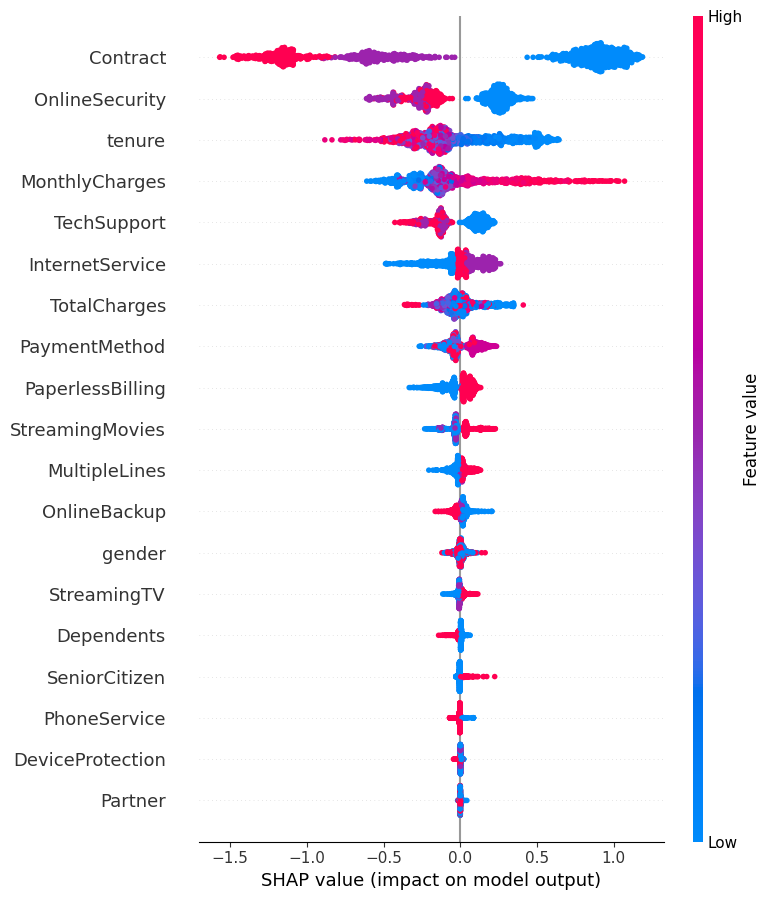

<Figure size 640x480 with 0 Axes>

In [36]:
# SHAP — Beeswarm plot (plus détaillé)
shap.summary_plot(shap_values, X_test)
plt.savefig('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/docs/shap_beeswarm.png',
            bbox_inches='tight')
plt.show()

In [37]:
# Choisir 3 clients types
y_pred_proba_test = model.predict_proba(X_test)[:, 1]

# Client 1 — Churner certain (score > 0.8)
idx_churner = (y_pred_proba_test > 0.8).nonzero()[0][0]

# Client 2 — Incertain (score entre 0.45 et 0.55)
idx_uncertain = ((y_pred_proba_test > 0.45) & 
                 (y_pred_proba_test < 0.55)).nonzero()[0][0]

# Client 3 — Fidèle (score < 0.2)
idx_loyal = (y_pred_proba_test < 0.2).nonzero()[0][0]

print(f"Churner score: {y_pred_proba_test[idx_churner]:.2f}")
print(f"Incertain score: {y_pred_proba_test[idx_uncertain]:.2f}")
print(f"Fidèle score: {y_pred_proba_test[idx_loyal]:.2f}")

Churner score: 0.80
Incertain score: 0.55
Fidèle score: 0.04


CLIENT 1 — CHURNER CERTAIN (score: 0.80)


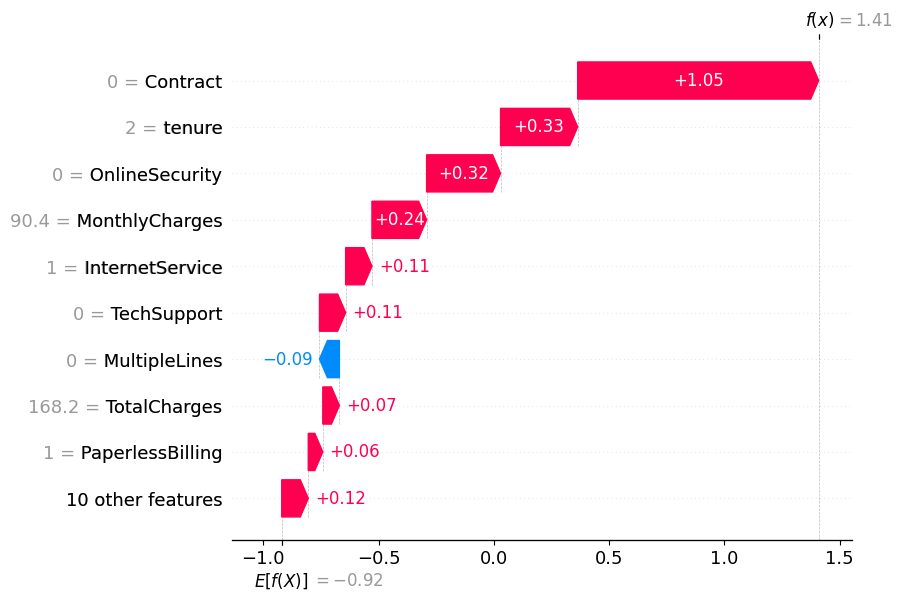

<Figure size 640x480 with 0 Axes>

In [38]:
# SHAP Waterfall — Client 1 : Churner certain
print("CLIENT 1 — CHURNER CERTAIN (score: 0.80)")
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx_churner],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx_churner],
    feature_names=X_test.columns.tolist()
))
plt.savefig('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/docs/shap_waterfall_churner.png',
            bbox_inches='tight')
plt.show()

CLIENT 2 — INCERTAIN (score: 0.55)


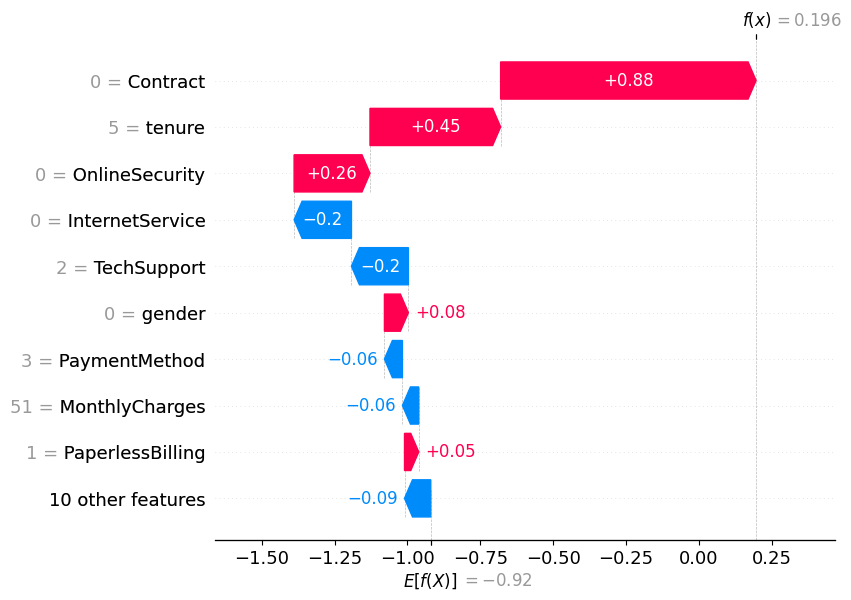

<Figure size 640x480 with 0 Axes>

In [39]:
# SHAP Waterfall — Client 2 : Incertain
print("CLIENT 2 — INCERTAIN (score: 0.55)")
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx_uncertain],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx_uncertain],
    feature_names=X_test.columns.tolist()
))
plt.savefig('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/docs/shap_waterfall_uncertain.png',
            bbox_inches='tight')
plt.show()

CLIENT 3 — FIDÈLE (score: 0.04)


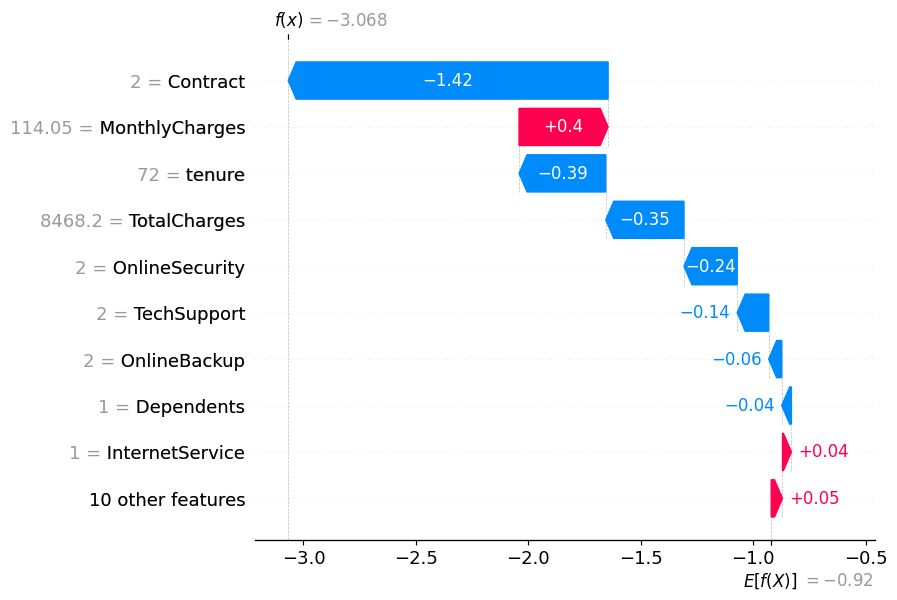

<Figure size 640x480 with 0 Axes>

In [40]:
# SHAP Waterfall — Client 3 : Fidèle
print("CLIENT 3 — FIDÈLE (score: 0.04)")
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx_loyal],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx_loyal],
    feature_names=X_test.columns.tolist()
))
plt.savefig('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/docs/shap_waterfall_loyal.png',
            bbox_inches='tight')
plt.show()

In [41]:
# ============================================
# LIME — Explications Locales
# ============================================
import lime
import lime.lime_tabular

# Créer l'explainer LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Churn', 'Churn'],
    mode='classification',
    random_state=42
)

print("✅ LIME explainer créé!")

✅ LIME explainer créé!


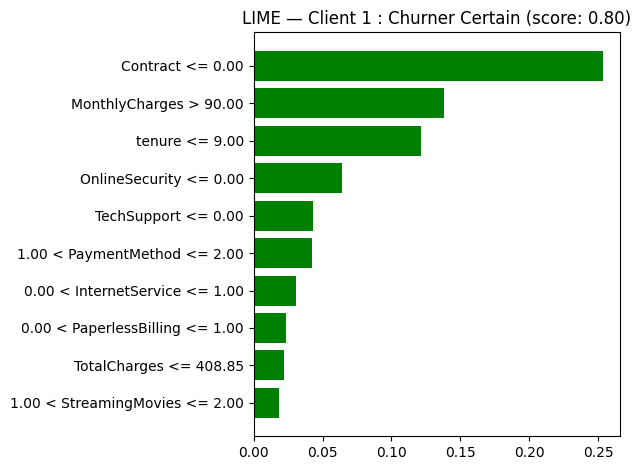

In [42]:
# LIME — Client 1 : Churner
lime_exp1 = lime_explainer.explain_instance(
    X_test.iloc[idx_churner].values,
    model.predict_proba,
    num_features=10
)
lime_exp1.as_pyplot_figure()
plt.title("LIME — Client 1 : Churner Certain (score: 0.80)")
plt.tight_layout()
plt.savefig('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/docs/lime_churner.png',
            bbox_inches='tight')
plt.show()

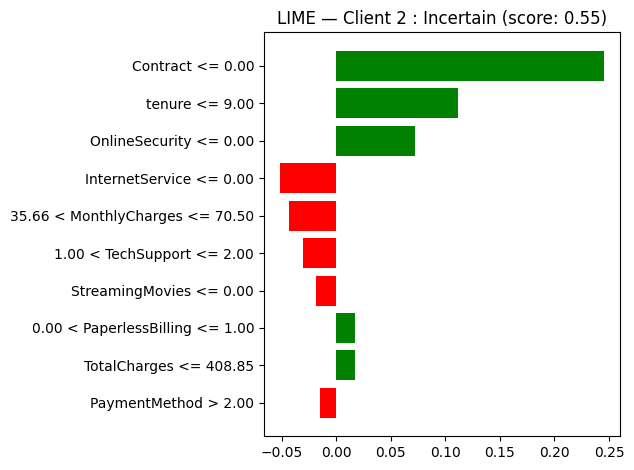

In [43]:
# LIME — Client 2 : Incertain
lime_exp2 = lime_explainer.explain_instance(
    X_test.iloc[idx_uncertain].values,
    model.predict_proba,
    num_features=10
)
lime_exp2.as_pyplot_figure()
plt.title("LIME — Client 2 : Incertain (score: 0.55)")
plt.tight_layout()
plt.savefig('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/docs/lime_uncertain.png',
            bbox_inches='tight')
plt.show()

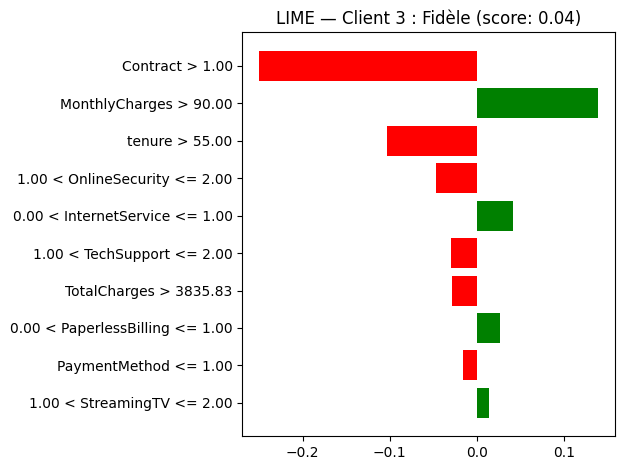

In [44]:
# LIME — Client 3 : Fidèle
lime_exp3 = lime_explainer.explain_instance(
    X_test.iloc[idx_loyal].values,
    model.predict_proba,
    num_features=10
)
lime_exp3.as_pyplot_figure()
plt.title("LIME — Client 3 : Fidèle (score: 0.04)")
plt.tight_layout()
plt.savefig('C:/Users/lenovo/Desktop/churn_prediction_xai_dashboard/docs/lime_loyal.png',
            bbox_inches='tight')
plt.show()